In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/ChronicKidneyDisease.csv'
df = pd.read_csv(file_path)
print(df)

       Bp     Sg   Al   Su  Rbc    Bu   Sc     Sod   Pot  Hemo    Wbcc  Rbcc  \
0    80.0  1.020  1.0  0.0  1.0  36.0  1.2  137.53  4.63  15.4  7800.0  5.20   
1    50.0  1.020  4.0  0.0  1.0  18.0  0.8  137.53  4.63  11.3  6000.0  4.71   
2    80.0  1.010  2.0  3.0  1.0  53.0  1.8  137.53  4.63   9.6  7500.0  4.71   
3    70.0  1.005  4.0  0.0  1.0  56.0  3.8  111.00  2.50  11.2  6700.0  3.90   
4    80.0  1.010  2.0  0.0  1.0  26.0  1.4  137.53  4.63  11.6  7300.0  4.60   
..    ...    ...  ...  ...  ...   ...  ...     ...   ...   ...     ...   ...   
395  80.0  1.020  0.0  0.0  1.0  49.0  0.5  150.00  4.90  15.7  6700.0  4.90   
396  70.0  1.025  0.0  0.0  1.0  31.0  1.2  141.00  3.50  16.5  7800.0  6.20   
397  80.0  1.020  0.0  0.0  1.0  26.0  0.6  137.00  4.40  15.8  6600.0  5.40   
398  60.0  1.025  0.0  0.0  1.0  50.0  1.0  135.00  4.90  14.2  7200.0  5.90   
399  80.0  1.025  0.0  0.0  1.0  18.0  1.1  141.00  3.50  15.8  6800.0  6.10   

     Htn  Class  
0    1.0      1  
1  

In [ ]:
print(df.head())
print(df.shape)

     Bp     Sg   Al   Su  Rbc    Bu   Sc     Sod   Pot  Hemo    Wbcc  Rbcc  \
0  80.0  1.020  1.0  0.0  1.0  36.0  1.2  137.53  4.63  15.4  7800.0  5.20   
1  50.0  1.020  4.0  0.0  1.0  18.0  0.8  137.53  4.63  11.3  6000.0  4.71   
2  80.0  1.010  2.0  3.0  1.0  53.0  1.8  137.53  4.63   9.6  7500.0  4.71   
3  70.0  1.005  4.0  0.0  1.0  56.0  3.8  111.00  2.50  11.2  6700.0  3.90   
4  80.0  1.010  2.0  0.0  1.0  26.0  1.4  137.53  4.63  11.6  7300.0  4.60   

   Htn  Class  
0  1.0      1  
1  0.0      1  
2  0.0      1  
3  1.0      1  
4  0.0      1  
(400, 14)


In [ ]:
print(df.isnull().sum())

Bp       0
Sg       0
Al       0
Su       0
Rbc      0
Bu       0
Sc       0
Sod      0
Pot      0
Hemo     0
Wbcc     0
Rbcc     0
Htn      0
Class    0
dtype: int64


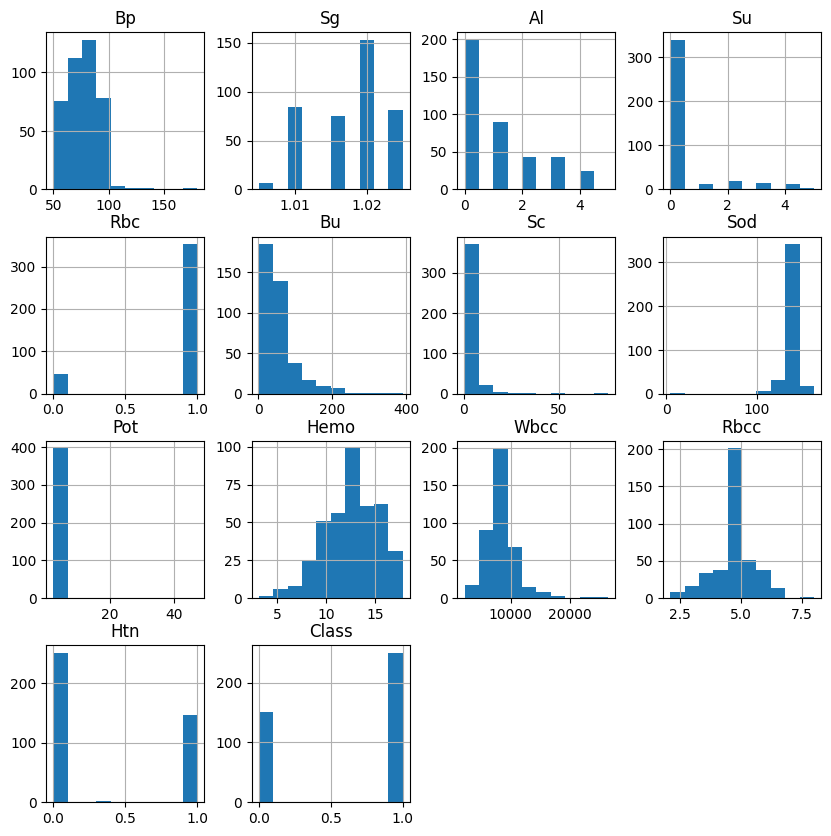

In [ ]:
df.hist(figsize=(10,10))
plt.show()

In [ ]:
x = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = dt.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("Accuracy:")
accuracy_score(y_test, y_pred)

Accuracy:


0.975

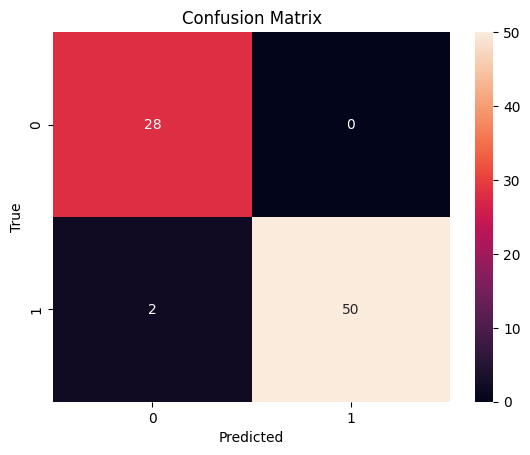

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
def predict_outcome():
  features = []
  for col in x.columns:
    value = float(input(f"Enter the value for {col}: "))
    features.append(value)
  features = np.array(features).reshape(1, -1)
  features = scaler.transform(features)
  prediction = dt.predict(features)
  if(prediction[0] == 1):
    print("PERSON MAY HAVE CHRONIC KIDNEY DISEASE")
  else:
    print("PERSON MAY NOT HAVE CHRONIC KIDNEY DISEASE")

In [ ]:
predict_outcome()

Enter the value for Bp: 80
Enter the value for Sg: 1.025
Enter the value for Al: 0
Enter the value for Su: 3
Enter the value for Rbc: 1
Enter the value for Bu: 49
Enter the value for Sc: 1.2
Enter the value for Sod: 137.53
Enter the value for Pot: 2.50
Enter the value for Hemo: 9.6
Enter the value for Wbcc: 6700
Enter the value for Rbcc: 5.20
Enter the value for Htn: 1
PERSON MAY NOT HAVE CHRONIC KIDNEY DISEASE


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
